##**Step 1:** Uploading the cleaned file

In [1]:
from google.colab import files
uploaded = files.upload()

Saving marketing_campaign_cleaned.csv to marketing_campaign_cleaned (1).csv


##**Step 2:** Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Purpose: StandardScaler normalizes features so no single feature dominates clustering due to scale differences. KMeans performs the actual clustering.

##**Step 3:** Load and Inspect

In [3]:
df = pd.read_csv('marketing_campaign_cleaned.csv')
print(df.shape)
print(df.isnull().sum().sum(), "total nulls")

# Purpose: Confirms you're working with the clean version, should show 0 nulls since you already handled them.

(2237, 29)
0 total nulls


**Data Load:**
Loaded the pre-cleaned marketing campaign dataset, confirmed zero missing values.

##**Step 4:** Build RFM Features

In [4]:
df['Frequency'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']
df['Monetary'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
                   df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])

rfm = df[['ID', 'Recency', 'Frequency', 'Monetary']]
rfm.describe()

# Purpose: RFM stands for Recency, Frequency, Monetary, the three classic behavioral metrics for segmentation. Recency already exists in the data. Frequency sums up purchases across all channels. Monetary sums total spend across all product categories.

,ID,Recency,Frequency,Monetary
count,2237.000000,2237.000000,2237.000000,2237.000000
mean,5590.726419,49.104604,12.544032,605.743406
std,3245.118591,28.956073,7.205919,601.840466
min,0.000000,0.000000,0.000000,5.000000
25%,2829.000000,24.000000,6.000000,69.000000
50%,5455.000000,49.000000,12.000000,396.000000
75%,8427.000000,74.000000,18.000000,1045.000000
max,11191.000000,99.000000,32.000000,2525.000000


**Feature Engineering: RFM**
Built three behavioral features: Recency (days since last purchase, already in the dataset), Frequency (total purchases across web, catalog, and store), and Monetary (total spend across all product categories).

##**Step 5:** Descriptive Statistics on RFM

In [5]:
print("Average purchase frequency:", rfm['Frequency'].mean())
print("Average monetary value: $", rfm['Monetary'].mean())
print("Average recency (days):", rfm['Recency'].mean())

# Purpose: Baseline understanding of typical customer behavior before clustering.

Average purchase frequency: 12.544032185963344
Average monetary value: $ 605.7434063477872
Average recency (days): 49.10460438086723


**Observation:**
On average, customers make roughly **12.5 purchases**, spend **$605.74 total**, with an average recency of **49.1 days** since their last purchase meaning most customers are shopping at least monthly.

##**Step 6:** Standardize the Features

In [6]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Purpose: K-Means clustering is distance-based, so features on different scales (Recency in days vs. Monetary in hundreds of dollars) would unfairly dominate. StandardScaler puts all three on the same scale (mean 0, standard deviation 1).

##**Step 7:** Elbow Method to Find Optimal K

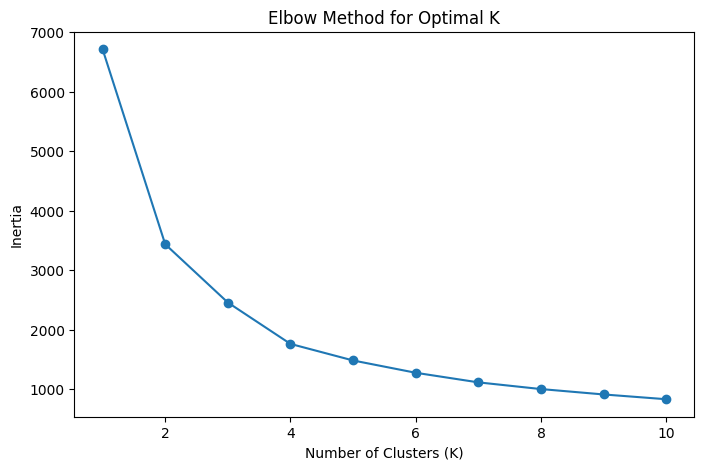

In [7]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

# Purpose: Inertia measures how tightly grouped each cluster is; it decreases as K increases, but at some point the improvement flattens out (the "elbow"). That bend point is the best trade-off between accuracy and simplicity.

**Observation:**
The elbow appears around K=4, indicating 4 is a reasonable number of customer segments — beyond this, adding more clusters gives diminishing returns.
(Adjust based on where your actual chart bends)

##**Step 8:** Apply K-Means with Chosen K

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(rfm_scaled)
df[['ID', 'Recency', 'Frequency', 'Monetary', 'Cluster']].head()

# Purpose: Runs the actual clustering and assigns each customer a cluster label (0, 1, 2, or 3).

,ID,Recency,Frequency,Monetary,Cluster
0,5524,58,22,1617,1
1,2174,38,4,27,2
2,4141,26,20,776,3
3,6182,26,6,53,2
4,5324,94,14,422,0


##**Step 9:** Visualize Clusters (Scatter Plots)

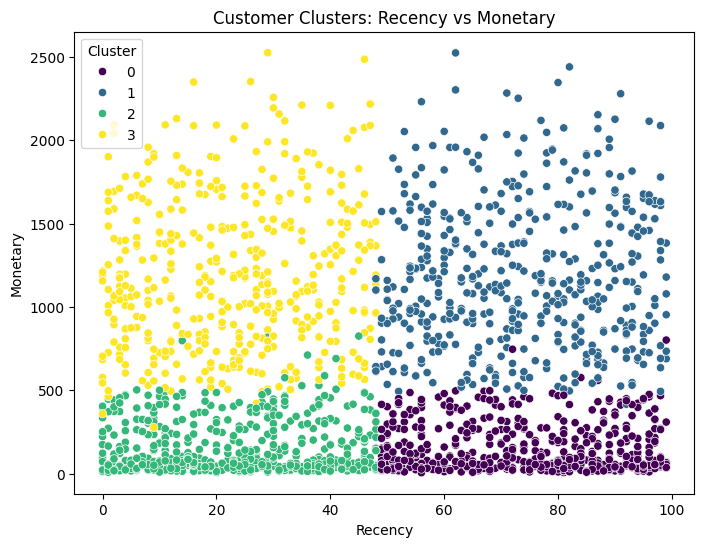

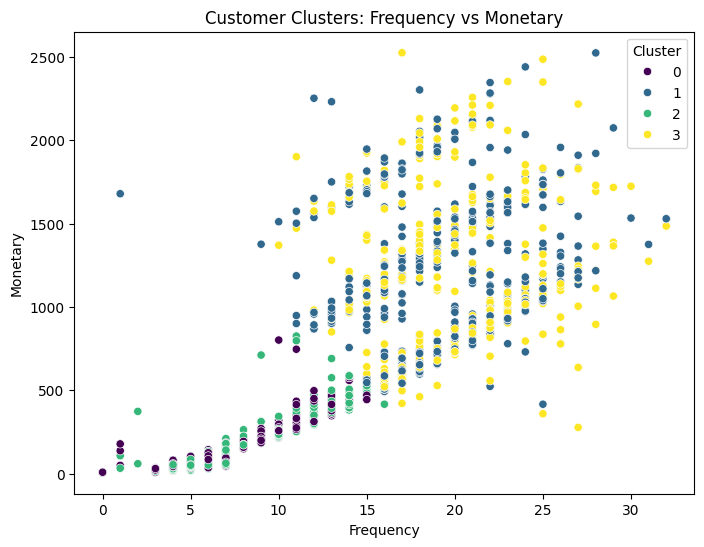

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Recency', y='Monetary', hue='Cluster', palette='viridis')
plt.title('Customer Clusters: Recency vs Monetary')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Frequency', y='Monetary', hue='Cluster', palette='viridis')
plt.title('Customer Clusters: Frequency vs Monetary')
plt.show()

# Purpose: Two different feature-pair views since 3D clustering can't be shown in a single 2D chart — this satisfies the "at least 2 feature combinations" requirement.

##**Step 10:** Profile Each Cluster

In [10]:
cluster_profile = df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_profile

# Purpose: Shows the average behavior per cluster, this is how you translate numbers into a "customer type" description.

,Recency,Frequency,Monetary
Cluster,,,
0,73.530159,7.015873,146.373016
1,73.145038,19.230916,1181.335878
2,23.521036,7.063107,151.577670
3,22.922581,19.782796,1183.092473


**Cluster Profiles:**

- **Cluster 0: Low-Value Lapsed Customers:** High recency (~ 74 days since last purchase), low frequency (~ 7 purchases), low monetary value (~ $146). These customers haven't bought recently and never spent much even when active; lowest priority segment.

- **Cluster 1: High-Value Lapsed Customers:** High recency (~ 73 days), but high frequency (~ 19 purchases) and high monetary value (~ $1,181). These were strong past customers who have gone quiet; a critical win-back opportunity, since they've already proven high lifetime value.

- **Cluster 2: Low-Value Active Customers:** Low recency (~ 24 days, recently active), but low frequency (~ 7 purchases) and low monetary value (~ $152). These are engaged but small-spending customers; good candidates for upselling.

- **Cluster 3: VIP Active Customers:** Low recency (~ 23 days, recently active), high frequency (~ 20 purchases), high monetary value (~ $1,183). These are your best customers; currently engaged AND high-spending. Top priority for retention and loyalty rewards.

##**Step 11:** Customer Count per Cluster

/tmp/ipykernel_1637/2622076811.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Cluster', palette='viridis')


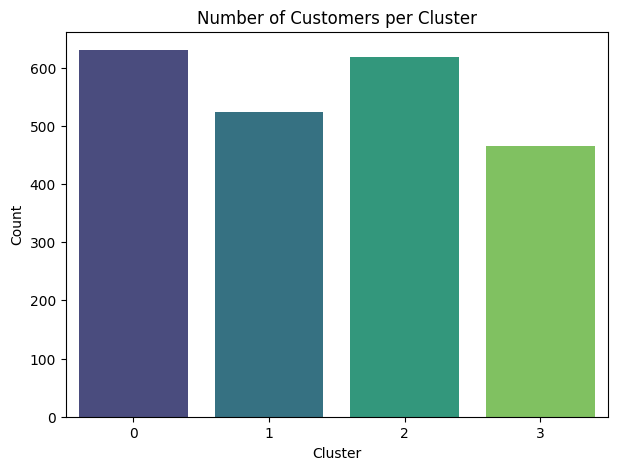

In [11]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Cluster', palette='viridis')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

# Purpose: Shows how large each segment is; a tiny "VIP" cluster vs. a large "average" cluster changes how you'd prioritize marketing budget.

##**Step 12:** Marketing Recommendations

## **Insights & Marketing Recommendations**
1. **VIP Active Customers (Cluster 3):** Highest priority reward with loyalty programs and early access to new products, since they're both highly engaged and high-spending.
2. **High-Value Lapsed Customers (Cluster 1):** Critical win-back opportunity these customers previously spent heavily but haven't purchased recently. Target with personalized re-engagement emails or targeted discounts.
3. **Low-Value Active Customers (Cluster 2):** Currently engaged but low-spending good candidates for upselling and cross-sell campaigns to increase their basket size.
4. **Low-Value Lapsed Customers (Cluster 0):** Lowest priority minimal marketing investment recommended, given both low historical value and inactivity.